# Exercício:

## Importe o .csv utilizado no exercício 7 da aula 11 e instancie um objeto da classe DataFrame. Considere que não à uma ordem entre os genes.
Como inserir  na DataFrame uma tabela de frequência do número de caracteres no nome dos genes? Uma vez inserida, como obter um gráfico de barras deste dado?

## 01 – Descreva o racional da sua resposta:

R.: Inserir uma coluna de frequencia dos caracteres em que ele faz a contagem da coluna 'Tamanho' com o value conts
Para a coluna ficar de acordo com os genes usei o .map
Para criar o gráfico foi feito um para cada gene no eixo x e as frequencias no eixo y 

## 02 – Desenhe o fluxograma da resposta:

<img src="../img/Fluxograma_ex11_1.png" width="400"/>

## 03 – Escreva o programa em Python:

In [96]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [77]:
genes_ex11 = pd.read_csv('genes.csv', index_col='Unnamed: 0')
genes_ex11

,Tamanho,Início,Contagem de A,Contém hu?
BCRA1,5,BC,1,False
TP53,4,TP,0,False
HLA-A,5,HL,2,False
SOD2,4,SO,0,False
APOE,4,AP,1,False


In [78]:
frequencia = genes_ex11['Tamanho'].value_counts().sort_index()
frequencia

Tamanho
4    3
5    2
Name: count, dtype: int64

In [79]:
genes_ex11['Frequencia'] = genes_ex11['Tamanho'].map(frequencia)
genes_ex11

,Tamanho,Início,Contagem de A,Contém hu?,Frequencia
BCRA1,5,BC,1,False,2
TP53,4,TP,0,False,3
HLA-A,5,HL,2,False,2
SOD2,4,SO,0,False,3
APOE,4,AP,1,False,3


Text(0.5, 0, 'Genes')

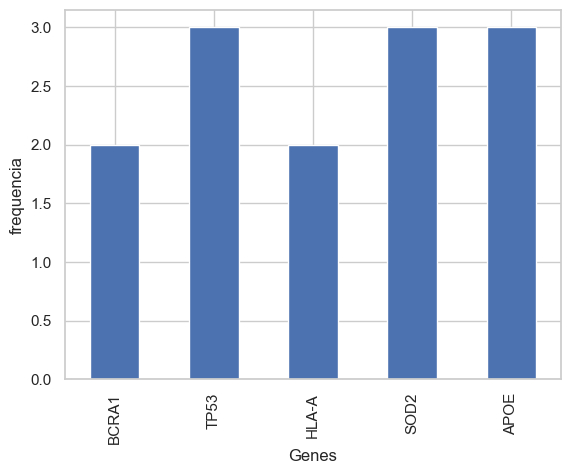

In [80]:
genes_ex11["Frequencia"].plot(kind='bar')

plt.ylabel("frequencia")
plt.xlabel('Genes')

## Importe o .csv utilizado no exercício 7 da aula 11 e instancie um objeto da classe DataFrame. Considere que à uma ordem entre os genes.
Como inserir  na DataFrame uma tabela de frequência do número de caracteres no nome dos genes? Uma vez inserida, como obter um gráfico de barras deste dado?

## 04 – Descreva o racional da sua resposta:

R.: instaciar uma nova df com a coluna de frequencia do outro dataframe organizada, renomeiei elas para fazer um novo dataframe
apos isso gerar um grafico e renomear os eixos x e y

## 05 – Desenhe o fluxograma da resposta:

<img src="../img/Fluxograma_ex11_2.png" width="400"/>

## 06 – Escreva o programa em Python:

In [81]:
freq_df = frequencia.reset_index()
freq_df.columns = ['Num_caracteres', 'Frequencia']

freq_df

,Num_caracteres,Frequencia
0,4,3
1,5,2


<Axes: xlabel='Num_caracteres'>

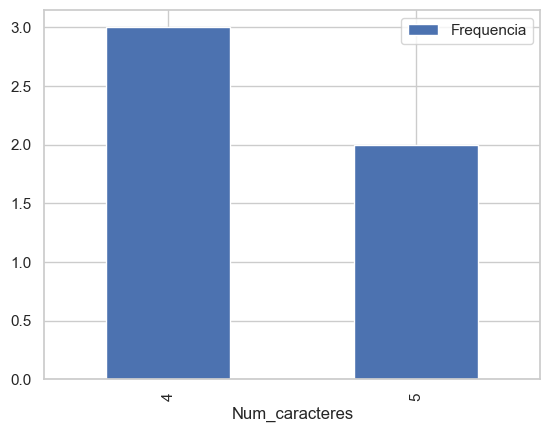

In [82]:
freq_df.plot(x='Num_caracteres', y='Frequencia', kind='bar')

## 07 – Reorganize a DataFrame, removendo as colunas contendo os dois primeiros caracteres, o número de caracter 'a', e a presença de 'hu', dos genes. Renomeie as colunas de acordo com as informações. Adicione uma coluna com a informação de 'Amostra 1'.

In [83]:
genes_ex11 = genes_ex11.drop(columns=['Início', 'Contagem de A', 'Contém hu?'])

In [84]:
genes_ex11

,Tamanho,Frequencia
BCRA1,5,2
TP53,4,3
HLA-A,5,2
SOD2,4,3
APOE,4,3


In [85]:
genes_ex11 = genes_ex11.rename(columns={'Tamanho' : 'Num_caracteres', 'Frequencia' : 'Frequencia_Carac'})
genes_ex11

,Num_caracteres,Frequencia_Carac
BCRA1,5,2
TP53,4,3
HLA-A,5,2
SOD2,4,3
APOE,4,3


In [86]:
genes_ex11['Amostra 1'] = np.random.randint(1, 10, 5)
genes_ex11

,Num_caracteres,Frequencia_Carac,Amostra 1
BCRA1,5,2,6
TP53,4,3,6
HLA-A,5,2,9
SOD2,4,3,2
APOE,4,3,7


## 08 – Usando a função randint(), da classe random do módulo numpy (np.random.randint(1,10,5)), instancie objeto da classe numpy array. Calcule as frequências desta nova amostra, considerando que à uma ordem entre os genes. Insira na DataFrame este objeto como "Amostra 2".

In [92]:
frequencia_amostra_2 = genes_ex11['Amostra 1'].value_counts()
frequencia_amostra_2

Amostra 1
6    2
9    1
2    1
7    1
Name: count, dtype: int64

In [93]:
genes_ex11['Amostra 2'] = genes_ex11['Amostra 1'].map(frequencia_amostra_2)
genes_ex11

,Num_caracteres,Frequencia_Carac,Amostra 1,Amostra 2
BCRA1,5,2,6,2
TP53,4,3,6,2
HLA-A,5,2,9,1
SOD2,4,3,2,1
APOE,4,3,7,1


## 09 – Repita o exercício 8, inserindo na DataFrame as replicas "Amostra 3“, "Amostra 4“, "Amostra 5“ e "Amostra 6".

In [94]:
for i in range(3, 7):
    nome_coluna = f'Amostra {i}'
    genes_ex11[nome_coluna] = np.random.randint(1, 10, 5)

genes_ex11

,Num_caracteres,Frequencia_Carac,Amostra 1,Amostra 2,Amostra 3,Amostra 4,Amostra 5,Amostra 6
BCRA1,5,2,6,2,3,9,5,5
TP53,4,3,6,2,6,4,7,7
HLA-A,5,2,9,1,5,9,6,9
SOD2,4,3,2,1,4,3,7,7
APOE,4,3,7,1,1,6,6,2


## 10 – Obtenha dos seus dados o gráfico abaixo, adicionando 3 replicas.

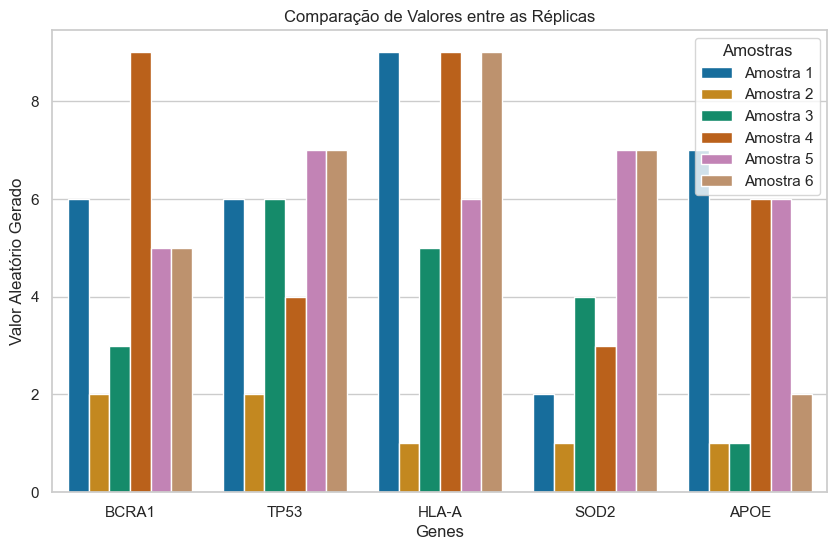

In [103]:
replicas = ['Amostra 1', 'Amostra 2', 'Amostra 3', 'Amostra 4', 'Amostra 5', 'Amostra 6']

plt.figure(figsize=(10, 6))
sns.set_theme(style="whitegrid")

df_plot = genes_ex11[replicas].reset_index()
df_plot = df_plot.melt(id_vars='index', var_name='Réplica', value_name='Valor')

sns.barplot(data=df_plot, x='index', y='Valor', hue='Réplica', palette='colorblind')


plt.title('Comparação de Valores entre as Réplicas')
plt.xlabel('Genes')
plt.ylabel('Valor Aleatório Gerado')
plt.legend(title='Amostras')
plt.show()